In [33]:
%env NX_CUGRAPH_AUTOCONFIG=True
import networkx as nx
from itertools import combinations
from collections import defaultdict, Counter
#import igraph as ig
import pandas as pd
import sqlite3
import random
from great_tables import GT, html

env: NX_CUGRAPH_AUTOCONFIG=True


In [3]:
conn = sqlite3.connect("tiktok_breadth_first.db")
cursor = conn.cursor()

In [4]:
query = """
SELECT hashtag_names
FROM videos
JOIN follow_relations
ON videos.reposter_username = follow_relations.from_username
WHERE follow_relations.to_username = 'kamalahq'
"""

kamalahq_docs = cursor.execute(query).fetchall()

In [16]:
query = """
SELECT hashtag_names
FROM videos
JOIN follow_relations
ON videos.reposter_username = follow_relations.from_username
WHERE follow_relations.to_username = 'teamtrump'
"""

teamtrump_docs = cursor.execute(query).fetchall()

In [5]:
kamalahq_token = Counter()
for doc in kamalahq_docs:
    contents = doc[0].lower().split(',')
    kamalahq_token.update(contents)

In [25]:
teamtrump_token = Counter()
for doc in teamtrump_docs:
    contents = doc[0].lower().split(',')
    teamtrump_token.update(contents)

In [27]:
kamalahq_edge_weights = defaultdict(int)
for doc in kamalahq_docs:
    contents = doc[0].lower().split(',')
    tokens = sorted(set(contents)) # sorted such that edge weight pairs are indexed alphabetically
    for u, v in combinations(tokens, 2):
        kamalahq_edge_weights[(u, v)] += 1

In [28]:
teamtrump_edge_weights = defaultdict(int)
for doc in teamtrump_docs:
    contents = doc[0].lower().split(',')
    tokens = sorted(set(contents)) # sorted such that edge weight pairs are indexed alphabetically
    for u, v in combinations(tokens, 2):
        teamtrump_edge_weights[(u, v)] += 1

In [ ]:
G_k = nx.Graph()
for (u, v), weight in kamalahq_edge_weights.items():
    G_k.add_edge(u, v, weight=weight)

In [29]:
G_t = nx.Graph()
for (u, v), weight in teamtrump_edge_weights.items():
    G_t.add_edge(u, v, weight=weight)

In [ ]:
nx.write_weighted_edgelist(G_k, 'kamalahq_hashtag_network.edgelist')

In [ ]:
nx.write_weighted_edgelist(G_t, 'teamtrump_hashtag_network.edgelist')

In [5]:
G_k = nx.read_weighted_edgelist('kamalahq_hashtag_network.edgelist')

In [6]:
G_t = nx.read_weighted_edgelist('teamtrump_hashtag_network.edgelist')

In [14]:
import json

In [69]:
nx.config.backend_priority = ["cugraph", "networkx"]

In [70]:
k_degree = nx.degree_centrality(G_k)

In [7]:
k_file_path = "k_degree.json"
with open(k_file_path, 'w') as json_file:
    json.dump(k_degree, json_file, indent=4)

In [8]:
t_degree = nx.degree_centrality(G_t)

In [9]:
t_file_path = "t_degree.json"
with open(t_file_path, 'w') as json_file:
    json.dump(t_degree, json_file, indent=4)

In [6]:
random.seed(42)
k_betweenness = nx.betweenness_centrality(G_k, k=50)

In [21]:
k_file_path = "k_betweenness.json"
with open(k_file_path, 'w') as json_file:
    json.dump(k_betweenness, json_file, indent=4)

In [9]:
random.seed(42)
t_betweenness = nx.betweenness_centrality(G_t, k=50)

In [22]:
t_file_path = "t_betweenness.json"
with open(t_file_path, 'w') as json_file:
    json.dump(t_betweenness, json_file, indent=4)

In [82]:
k_pagerank = nx.pagerank(G_k, weight='weight')

In [83]:
k_file_path = "k_pagerank.json"
with open(k_file_path, 'w') as json_file:
    json.dump(k_pagerank, json_file, indent=4)

In [84]:
t_pagerank = nx.pagerank(G_t, weight='weight')

In [85]:
t_file_path = "t_pagerank.json"
with open(t_file_path, 'w') as json_file:
    json.dump(t_pagerank, json_file, indent=4)

In [86]:
measures = ['betweenness', 'degree', 'pagerank']
k_measures_df = pd.DataFrame({})
for m in measures:
    with open(f'k_{m}.json') as f:
        data = json.load(f)
    df = pd.DataFrame(data.values(), index=data.keys(), columns = [m])
    k_measures_df = pd.concat([k_measures_df, df], axis=1)

In [87]:
measures = ['betweenness', 'degree', 'pagerank']
t_measures_df = pd.DataFrame({})
for m in measures:
    with open(f't_{m}.json') as f:
        data = json.load(f)
    df = pd.DataFrame(data.values(), index=data.keys(), columns = [m])
    t_measures_df = pd.concat([t_measures_df, df], axis=1)

In [88]:
k_measures_df.to_csv('kamala_nodes_measure.csv')
t_measures_df.to_csv('trump_nodes_measure.csv')

In [10]:
from networkx import approximation

In [11]:
t_avg_cluster = approximation.average_clustering(G_t, trials=100000, seed=42)
k_avg_cluster = approximation.average_clustering(G_k, trials=100000, seed=42)

In [12]:
k_max_comp = max(nx.connected_components(G_k), key=len)
t_max_comp = max(nx.connected_components(G_t), key=len)

In [13]:
k_diameter = approximation.diameter(nx.induced_subgraph(G_k, k_max_comp), seed=42)
t_diameter = approximation.diameter(nx.induced_subgraph(G_t, t_max_comp), seed=42)

In [14]:
t_avg_cluster, k_avg_cluster

(0.84527, 0.84437)

In [15]:
t_density = nx.density(G_t)
k_density = nx.density(G_k)

In [16]:
t_density, k_density

(0.00014269010099396336, 8.91057180921317e-05)

In [17]:
t_nnodes = nx.number_of_nodes(G_t)
k_nnodes = nx.number_of_nodes(G_k)

In [18]:
t_nnodes, k_nnodes

(246620, 487200)

In [19]:
t_nedges = nx.number_of_edges(G_t)
k_nedges = nx.number_of_edges(G_k)

In [64]:
t_nedges, k_nedges

(4339290, 10575216)

In [7]:
t_assortativity = nx.degree_assortativity_coefficient(G_t, weight='weight')
k_assortativity = nx.degree_assortativity_coefficient(G_k, weight='weight')

In [8]:
t_assortativity, k_assortativity

(-0.03875800665174091, -0.03677971268168211)

In [20]:
stats_df = pd.DataFrame({
    'Metric': [
        'Number of Nodes',
        'Number of Edges',
        'Density',
        'Average Clustering Coeff',
        'Degree Assortativity',
        'Diameter (Maximal Component)',
        
    ],
    'Harris': [
        str(k_nnodes),
        str(k_nedges),
        f'{k_density:.4e}',
        k_avg_cluster,
        round(k_assortativity, 4),
        str(k_diameter)
    ],
    'Trump': [
        str(t_nnodes),
        str(t_nedges),
        f'{t_density:.4e}',
        t_avg_cluster,
        round(t_assortativity, 4),
        str(t_diameter)
    ]
})

In [21]:
stats_df.head()

,Metric,Harris,Trump
0,Number of Nodes,487200,246620
1,Number of Edges,10575216,4339290
2,Density,8.9106e-05,1.4269e-04
3,Average Clustering Coeff,0.84437,0.84527
4,Degree Assortativity,-0.0368,-0.0388


In [22]:
basic_stats = GT(stats_df).tab_header(title='Networks Overview: Harris vs. Trump')
basic_stats.save('viz/gt_network_stats.png')

GT(_tbl_data=                         Metric      Harris       Trump
0               Number of Nodes      487200      246620
1               Number of Edges    10575216     4339290
2                       Density  8.9106e-05  1.4269e-04
3      Average Clustering Coeff     0.84437     0.84527
4          Degree Assortativity     -0.0368     -0.0388
5  Diameter (Maximal Component)          11           9, _body=<great_tables._gt_data.Body object at 0x7effd211d490>, _boxhead=Boxhead([ColInfo(var='Metric', type=<ColInfoTypeEnum.default: 1>, column_label='Metric', column_align='left', column_width=None), ColInfo(var='Harris', type=<ColInfoTypeEnum.default: 1>, column_label='Harris', column_align='left', column_width=None), ColInfo(var='Trump', type=<ColInfoTypeEnum.default: 1>, column_label='Trump', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7efd6be85310>, _spanners=Spanners([]), _heading=Heading(title='Networks Overview: Harris vs. Trump', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7efd6beb4550>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7efd6beb5b50>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7efd6be854d0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_colo

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [49]:
k_measures_df = pd.read_csv('kamala_nodes_measure.csv')
k_measures_df.rename(columns={'Unnamed: 0': 'hashtag'}, inplace=True)
t_measures_df = pd.read_csv('trump_nodes_measure.csv')
t_measures_df.rename(columns={'Unnamed: 0': 'hashtag'}, inplace=True)

In [50]:
k_measures_df['candidate'] = ['kamalahq'] * len(k_measures_df)
t_measures_df['candidate'] = ['teamtrump'] * len(t_measures_df)

In [51]:
nodes_df = pd.concat([k_measures_df, t_measures_df])

In [19]:
nodes_df.head()

,hashtag,betweenness,degree,pagerank,candidate
0,ahs,1.887389e-05,0.001576,0.000025,kamalahq
1,blancaevangelista,1.689217e-07,0.000070,0.000001,kamalahq
2,edit,2.847784e-02,0.148003,0.006867,kamalahq
3,fypシ,3.650446e-02,0.159980,0.007019,kamalahq
4,posefx,3.073150e-06,0.000400,0.000009,kamalahq


In [42]:
# zipping degree dist with their respective numbers
k_node_dist = {d*(1000000)/G_k.number_of_nodes(): freq for d, freq in enumerate(nx.degree_histogram(G_k)) if freq > 0}
t_node_dist = {d*(1000000)/G_t.number_of_nodes(): freq for d, freq in enumerate(nx.degree_histogram(G_t)) if freq > 0}

In [56]:
k_degree_df = pd.DataFrame.from_dict(k_node_dist, orient='index', columns=['frequency']).reset_index(names=['degree'])
t_degree_df = pd.DataFrame.from_dict(t_node_dist, orient='index', columns=['frequency']).reset_index(names=['degree'])
k_degree_df['candidate'] = ['kamalahq'] *len(k_degree_df)
t_degree_df['candidate'] = ['teamtrump'] *len(t_degree_df)

In [58]:
node_degree_df = pd.concat([k_degree_df, t_degree_df])

/scratch/local/jobs/47704240/ipykernel_2332053/3728500465.py:20: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1.0)


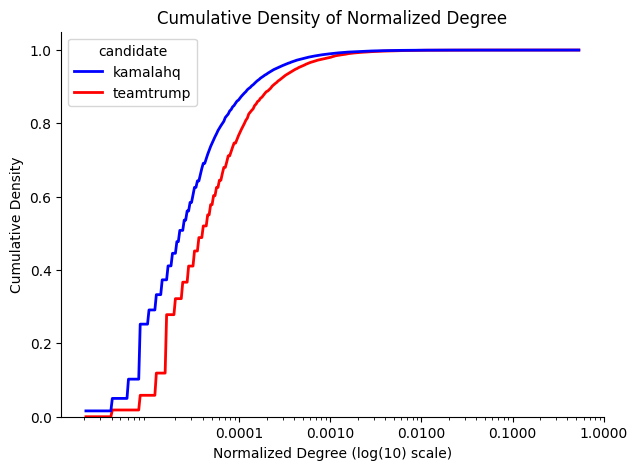

In [131]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)

sns.histplot(
    nodes_df,
    x='degree', hue="candidate",
    #multiple="stack",
    palette={'kamalahq': 'blue',
             'teamtrump': 'red'},
    linewidth=2,
    log_scale=True,
    element='poly',
    stat='density',
    cumulative=True,
    #kde=True,
    fill=False,
    common_norm=False
)
ax.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
plt.xlim(0, 1.0)
plt.xlabel('Normalized Degree (log(10) scale)')
plt.ylabel('Cumulative Density')
plt.title('Cumulative Density of Normalized Degree')
ax.set_xticks([0.0001, 0.001, 0.01, 0.1, 1])
plt.savefig('viz/degree_density.png')

In [92]:
from scipy import stats
import numpy as np

print('Mean Degree T-test')

k_degree_list = nodes_df[nodes_df['candidate']=='kamalahq']['degree'].to_list()
t_degree_list = nodes_df[nodes_df['candidate']=='teamtrump']['degree'].to_list()
print(f'Harris mean: {np.mean(k_degree_list)}')
print(f'Trump mean: {np.mean(t_degree_list)}')
print(f'Harris SD: {np.std(k_degree_list)}')
print(f'Trump SD: {np.std(t_degree_list)}')

t_stat_degree, p_val_degree = stats.ttest_ind(k_degree_list, t_degree_list, equal_var=False)
print(f"T-statistic: {t_stat_degree:.4f}, P-value: {p_val_degree:.4f}")

if p_val_degree < 0.05:
    print("Significant difference (reject H0)")
else:
    print("No significant difference (fail to reject H0)")

Mean Degree T-test
Harris mean: 8.910571809212498e-05
Trump mean: 0.00014269010099395168
Harris SD: 0.0012115144126634142
Trump SD: 0.001475800138282428
T-statistic: -15.5700, P-value: 0.0000
Significant difference (reject H0)


In [93]:
print('Mean Betweenness T-test')

k_betweenness_list = nodes_df[nodes_df['candidate']=='kamalahq']['betweenness'].to_list()
t_betweenness_list = nodes_df[nodes_df['candidate']=='teamtrump']['betweenness'].to_list()
print(f'Harris mean: {np.mean(k_betweenness_list)}')
print(f'Trump mean: {np.mean(t_betweenness_list)}')
print(f'Harris SD: {np.std(k_betweenness_list)}')
print(f'Trump SD: {np.std(t_betweenness_list)}')

t_stat_betweenness, p_val_betweenness = stats.ttest_ind(k_betweenness_list, t_betweenness_list, equal_var=False)
print(f"T-statistic: {t_stat_betweenness:.4f}, P-value: {p_val_betweenness:.4f}")

if p_val_betweenness < 0.05:
    print("Significant difference (reject H0)")
else:
    print("No significant difference (fail to reject H0)")

Mean Betweenness T-test
Harris mean: 3.3848884925540347e-06
Trump mean: 6.934189863465794e-06
Harris SD: 0.0005418457112621544
Trump SD: 0.0008063300868770744
T-statistic: -1.9722, P-value: 0.0486
Significant difference (reject H0)


In [94]:
print('Mean Pagerank T-test')

k_pagerank_list = nodes_df[nodes_df['candidate']=='kamalahq']['pagerank'].to_list()
t_pagerank_list = nodes_df[nodes_df['candidate']=='teamtrump']['pagerank'].to_list()
print(f'Harris mean: {np.mean(k_pagerank_list)}')
print(f'Trump mean: {np.mean(t_pagerank_list)}')
print(f'Harris SD: {np.std(k_pagerank_list)}')
print(f'Trump SD: {np.std(t_pagerank_list)}')

t_stat_pagerank, p_val_pagerank = stats.ttest_ind(k_pagerank_list, t_pagerank_list, equal_var=False)
print(f"T-statistic: {t_stat_pagerank:.4f}, P-value: {p_val_pagerank:.4f}")

if p_val_pagerank < 0.05:
    print("Significant difference (reject H0)")
else:
    print("No significant difference (fail to reject H0)")

Mean Pagerank T-test
Harris mean: 2.0525451559934378e-06
Trump mean: 4.05482118238572e-06
Harris SD: 7.403143499679376e-05
Trump SD: 9.59828794866723e-05
T-statistic: -9.0820, P-value: 0.0000
Significant difference (reject H0)


In [124]:
ttest_dict = {'Metric': ['Node Degree', 'Node Betweenness', 'Node Pagerank'],
              'Harris Mean': [f'{np.mean(k_degree_list):.2e}', f'{np.mean(k_betweenness_list):.2e}',\
                               f'{np.mean(k_pagerank_list):.2e}'],
              'Harris SD': [f'{np.std(k_degree_list):.2e}', f'{np.std(k_betweenness_list):.2e}',\
                            f'{np.std(k_pagerank_list):.2e}'],
              'Trump Mean': [f'{np.mean(t_degree_list):.2e}', f'{np.mean(t_betweenness_list):.2e}',\
                             f'{np.mean(t_pagerank_list):.2e}'],
              'Trump SD': [f'{np.std(t_degree_list):.2e}', f'{np.std(t_betweenness_list):.2e}',\
                           f'{np.std(t_pagerank_list):.2e}'],
              't-statistic': [str(round(t_stat_degree, 3)) + '***' , str(round(t_stat_betweenness, 3)) + '*',\
                              str(round(t_stat_pagerank, 3)) + '***'],
              }

In [125]:
ttest_df = pd.DataFrame(ttest_dict)
ttest_df.to_csv('network_t_test.csv')

In [126]:
ttest_table = GT(ttest_df)
ttest_table

Metric,Harris Mean,Harris SD,Trump Mean,Trump SD,t-statistic
Node Degree,8.91e-05,1.21e-03,1.43e-04,1.48e-03,-15.57***
Node Betweenness,3.38e-06,5.42e-04,6.93e-06,8.06e-04,-1.972*
Node Pagerank,2.05e-06,7.40e-05,4.05e-06,9.60e-05,-9.082***


In [128]:
ttest_table.save('viz/network_t_test.png')

Metric,Harris Mean,Harris SD,Trump Mean,Trump SD,t-statistic
Node Degree,8.91e-05,1.21e-03,1.43e-04,1.48e-03,-15.57***
Node Betweenness,3.38e-06,5.42e-04,6.93e-06,8.06e-04,-1.972*
Node Pagerank,2.05e-06,7.40e-05,4.05e-06,9.60e-05,-9.082***


In [7]:
k_node_measures = pd.read_csv('kamala_nodes_measure.csv')
t_node_measures = pd.read_csv('trump_nodes_measure.csv')
k_node_measures.rename(columns={'Unnamed: 0':'hashtag'}, inplace=True)
t_node_measures.rename(columns={'Unnamed: 0':'hashtag'}, inplace=True)

,hashtag,betweenness,degree,pagerank
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
487195,False,False,False,False
487196,False,False,False,False
487197,False,False,False,False
487198,False,False,False,False


In [38]:
k_measures_df = {'Degree': k_node_measures.sort_values(by='degree', ascending=False)['hashtag'].iloc[:10].to_list(),
                 'Val1': k_node_measures.sort_values(by='degree', ascending=False)['degree'].iloc[:10].to_list(),
                 'Betweenness': k_node_measures.sort_values(by='betweenness', ascending=False)['hashtag'].iloc[:10].to_list(),
                 'Val2':k_node_measures.sort_values(by='betweenness', ascending=False)['betweenness'].iloc[:10].to_list(),
                'Pagerank': k_node_measures.sort_values(by='pagerank', ascending=False)['hashtag'].iloc[:10].to_list(),
                'Val3': k_node_measures.sort_values(by='pagerank', ascending=False)['pagerank'].iloc[:10].to_list(), 

}
k_measures_df = pd.DataFrame(k_measures_df)
k_measures_df = round(k_measures_df, 4)

In [37]:
k_measures_df

,Degree,Val1,Betweenness,Val2,Pagerank,Val3
0,fyp,0.5426,fyp,0.3516,fyp,0.0432
1,viral,0.2687,viral,0.0710,viral,0.0163
2,foryou,0.2213,foryoupage,0.0684,foryou,0.0109
3,foryoupage,0.2196,foryou,0.0465,foryoupage,0.0109
4,fypシ,0.1600,fypシ,0.0365,fypシ,0.0070
5,edit,0.1480,edit,0.0285,edit,0.0069
6,trending,0.1067,art,0.0245,relatable,0.0051
7,fypシ゚viral,0.0942,fy,0.0234,trending,0.0043
8,fy,0.0940,funny,0.0231,funny,0.0042
9,fyppppppppppppppppppppppp,0.0915,goviraltiktok♥️,0.0198,xyzbca,0.0037


In [39]:
t_measures_df = {'Degree': t_node_measures.sort_values(by='degree', ascending=False)['hashtag'].iloc[:10].to_list(),
                 'Val1': t_node_measures.sort_values(by='degree', ascending=False)['degree'].iloc[:10].to_list(),
                 'Betweenness': t_node_measures.sort_values(by='betweenness', ascending=False)['hashtag'].iloc[:10].to_list(),
                 'Val2':t_node_measures.sort_values(by='betweenness', ascending=False)['betweenness'].iloc[:10].to_list(),
                'Pagerank': t_node_measures.sort_values(by='pagerank', ascending=False)['hashtag'].iloc[:10].to_list(),
                'Val3': t_node_measures.sort_values(by='pagerank', ascending=False)['pagerank'].iloc[:10].to_list(), 

}
t_measures_df = pd.DataFrame(t_measures_df)
t_measures_df = round(t_measures_df, 4)

In [40]:
t_measures_df

,Degree,Val1,Betweenness,Val2,Pagerank,Val3
0,fyp,0.4882,fyp,0.3755,fyp,0.0401
1,viral,0.2429,viral,0.0755,viral,0.0157
2,foryou,0.1943,foryou,0.0729,foryou,0.0104
3,foryoupage,0.1735,foryoupage,0.0428,foryoupage,0.0086
4,fypシ,0.1208,edit,0.0286,edit,0.0057
5,edit,0.1079,capcut,0.0275,fypシ,0.0054
6,trending,0.0937,fypシ,0.0225,relatable,0.0041
7,fy,0.0846,sharinganeyes,0.0195,trending,0.0038
8,funny,0.0754,christmas,0.0192,funny,0.0037
9,relatable,0.0753,history,0.0179,fy,0.0032


In [42]:
gt_k_central_nodes = (
    GT(k_measures_df)
    .tab_header(
        title="Harris High Centrality Nodes",
        subtitle="Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality",
    )
    .tab_spanner(label="Degree", columns=["Degree", "Val1"])
    .tab_spanner(label="Betweenness", columns=["Betweenness", "Val2"])
    .tab_spanner(label="Pagerank", columns=["Pagerank", "Val3"])
    .cols_label(
        Degree=html("Hashtag"),
        Val1=html("Value"),
        Betweenness=html("Hashtag"),
        Val2 = html("Value"),
        Pagerank=html("Hashtag"),
        Val3=html("Value"),
    )
    .tab_options(
    heading_background_color="blue"
)
)

gt_k_central_nodes

GT(_tbl_data=                      Degree    Val1      Betweenness    Val2    Pagerank  \
0                        fyp  0.5426              fyp  0.3516         fyp   
1                      viral  0.2687            viral  0.0710       viral   
2                     foryou  0.2213       foryoupage  0.0684      foryou   
3                 foryoupage  0.2196           foryou  0.0465  foryoupage   
4                       fypシ  0.1600             fypシ  0.0365        fypシ   
5                       edit  0.1480             edit  0.0285        edit   
6                   trending  0.1067              art  0.0245   relatable   
7                 fypシ゚viral  0.0942               fy  0.0234    trending   
8                         fy  0.0940            funny  0.0231       funny   
9  fyppppppppppppppppppppppp  0.0915  goviraltiktok♥️  0.0198      xyzbca   

     Val3  
0  0.0432  
1  0.0163  
2  0.0109  
3  0.0109  
4  0.0070  
5  0.0069  
6  0.0051  
7  0.0043  
8  0.0042  
9  0.0037  , _body=<great_tables._gt_data.Body object at 0x7f0c8d860990>, _boxhead=Boxhead([ColInfo(var='Degree', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Betweenness', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val2', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Pagerank', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val3', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f0c8d86d710>, _spanners=Spanners([SpannerInfo(spanner_id='Degree', spanner_level=0, spanner_label='Degree', spanner_units=None, spanner_pattern=None, vars=['Degree', 'Val1'], built=None), SpannerInfo(spanner_id='Betweenness', spanner_level=0, spanner_label='Betweenness', spanner_units=None, spanner_pattern=None, vars=['Betweenness', 'Val2'], built=None), SpannerInfo(spanner_id='Pagerank', spanner_level=0, spanner_label='Pagerank', spanner_units=None, spanner_pattern=None, vars=['Pagerank', 'Val3'], built=None)]), _heading=Heading(title='Harris High Centrality Nodes', subtitle='Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f0c7c3d8590>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f0c7c3d9050>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f0c7c3db710>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', 

In [44]:
gt_k_central_nodes.save('viz/kamala_high_centrality.png')

GT(_tbl_data=                      Degree    Val1      Betweenness    Val2    Pagerank  \
0                        fyp  0.5426              fyp  0.3516         fyp   
1                      viral  0.2687            viral  0.0710       viral   
2                     foryou  0.2213       foryoupage  0.0684      foryou   
3                 foryoupage  0.2196           foryou  0.0465  foryoupage   
4                       fypシ  0.1600             fypシ  0.0365        fypシ   
5                       edit  0.1480             edit  0.0285        edit   
6                   trending  0.1067              art  0.0245   relatable   
7                 fypシ゚viral  0.0942               fy  0.0234    trending   
8                         fy  0.0940            funny  0.0231       funny   
9  fyppppppppppppppppppppppp  0.0915  goviraltiktok♥️  0.0198      xyzbca   

     Val3  
0  0.0432  
1  0.0163  
2  0.0109  
3  0.0109  
4  0.0070  
5  0.0069  
6  0.0051  
7  0.0043  
8  0.0042  
9  0.0037  , _body=<great_tables._gt_data.Body object at 0x7f0c8d860990>, _boxhead=Boxhead([ColInfo(var='Degree', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Betweenness', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val2', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Pagerank', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val3', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f0c8d86d710>, _spanners=Spanners([SpannerInfo(spanner_id='Degree', spanner_level=0, spanner_label='Degree', spanner_units=None, spanner_pattern=None, vars=['Degree', 'Val1'], built=None), SpannerInfo(spanner_id='Betweenness', spanner_level=0, spanner_label='Betweenness', spanner_units=None, spanner_pattern=None, vars=['Betweenness', 'Val2'], built=None), SpannerInfo(spanner_id='Pagerank', spanner_level=0, spanner_label='Pagerank', spanner_units=None, spanner_pattern=None, vars=['Pagerank', 'Val3'], built=None)]), _heading=Heading(title='Harris High Centrality Nodes', subtitle='Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f0c7c3d8590>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f0c7c3d9050>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f0c7c3db710>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', 

In [43]:
gt_t_central_nodes = (
    GT(t_measures_df)
    .tab_header(
        title="Trump High Centrality Nodes",
        subtitle="Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality",
    )
    .tab_spanner(label="Degree", columns=["Degree", "Val1"])
    .tab_spanner(label="Betweenness", columns=["Betweenness", "Val2"])
    .tab_spanner(label="Pagerank", columns=["Pagerank", "Val3"])
    .cols_label(
        Degree=html("Hashtag"),
        Val1=html("Value"),
        Betweenness=html("Hashtag"),
        Val2 = html("Value"),
        Pagerank=html("Hashtag"),
        Val3=html("Value"),
    )
    .tab_options(
    heading_background_color="red"
)
)

gt_t_central_nodes

GT(_tbl_data=       Degree    Val1    Betweenness    Val2    Pagerank    Val3
0         fyp  0.4882            fyp  0.3755         fyp  0.0401
1       viral  0.2429          viral  0.0755       viral  0.0157
2      foryou  0.1943         foryou  0.0729      foryou  0.0104
3  foryoupage  0.1735     foryoupage  0.0428  foryoupage  0.0086
4        fypシ  0.1208           edit  0.0286        edit  0.0057
5        edit  0.1079         capcut  0.0275        fypシ  0.0054
6    trending  0.0937           fypシ  0.0225   relatable  0.0041
7          fy  0.0846  sharinganeyes  0.0195    trending  0.0038
8       funny  0.0754      christmas  0.0192       funny  0.0037
9   relatable  0.0753        history  0.0179          fy  0.0032, _body=<great_tables._gt_data.Body object at 0x7f0c7c3c8990>, _boxhead=Boxhead([ColInfo(var='Degree', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Betweenness', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val2', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Pagerank', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val3', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f0c8d84a950>, _spanners=Spanners([SpannerInfo(spanner_id='Degree', spanner_level=0, spanner_label='Degree', spanner_units=None, spanner_pattern=None, vars=['Degree', 'Val1'], built=None), SpannerInfo(spanner_id='Betweenness', spanner_level=0, spanner_label='Betweenness', spanner_units=None, spanner_pattern=None, vars=['Betweenness', 'Val2'], built=None), SpannerInfo(spanner_id='Pagerank', spanner_level=0, spanner_label='Pagerank', spanner_units=None, spanner_pattern=None, vars=['Pagerank', 'Val3'], built=None)]), _heading=Heading(title='Trump High Centrality Nodes', subtitle='Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f0c8d892410>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f0c8d891d90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f0c8d890a90>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='

In [45]:
gt_t_central_nodes.save('viz/trump_high_centrality.png')

GT(_tbl_data=       Degree    Val1    Betweenness    Val2    Pagerank    Val3
0         fyp  0.4882            fyp  0.3755         fyp  0.0401
1       viral  0.2429          viral  0.0755       viral  0.0157
2      foryou  0.1943         foryou  0.0729      foryou  0.0104
3  foryoupage  0.1735     foryoupage  0.0428  foryoupage  0.0086
4        fypシ  0.1208           edit  0.0286        edit  0.0057
5        edit  0.1079         capcut  0.0275        fypシ  0.0054
6    trending  0.0937           fypシ  0.0225   relatable  0.0041
7          fy  0.0846  sharinganeyes  0.0195    trending  0.0038
8       funny  0.0754      christmas  0.0192       funny  0.0037
9   relatable  0.0753        history  0.0179          fy  0.0032, _body=<great_tables._gt_data.Body object at 0x7f0c7c3c8990>, _boxhead=Boxhead([ColInfo(var='Degree', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Betweenness', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val2', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None), ColInfo(var='Pagerank', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Hashtag'), column_align='left', column_width=None), ColInfo(var='Val3', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='Value'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f0c8d84a950>, _spanners=Spanners([SpannerInfo(spanner_id='Degree', spanner_level=0, spanner_label='Degree', spanner_units=None, spanner_pattern=None, vars=['Degree', 'Val1'], built=None), SpannerInfo(spanner_id='Betweenness', spanner_level=0, spanner_label='Betweenness', spanner_units=None, spanner_pattern=None, vars=['Betweenness', 'Val2'], built=None), SpannerInfo(spanner_id='Pagerank', spanner_level=0, spanner_label='Pagerank', spanner_units=None, spanner_pattern=None, vars=['Pagerank', 'Val3'], built=None)]), _heading=Heading(title='Trump High Centrality Nodes', subtitle='Top 10 Hashtags for Degree, Betweenness and Pagerank Centrality', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f0c8d892410>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f0c8d891d90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f0c8d890a90>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='